--- CURRENT DATASET BALANCE ---
vibe
Casual Basics                469
Business Casual              401
Streetwear                   390
Traditional / Ethnic Wear    309
Athleisure                   210
Edgy / Alternative           130
Boho / Cottagecore            91
Loungewear / Sleepwear        70
Business Formal               58
Name: count, dtype: int64

Total Clean Samples: 2128


/var/folders/1c/cd6gjfxx7k7b0lh7ckrkfrnc0000gn/T/ipykernel_53416/1293630593.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y="vibe", order=df_clean['vibe'].value_counts().index, palette="viridis")


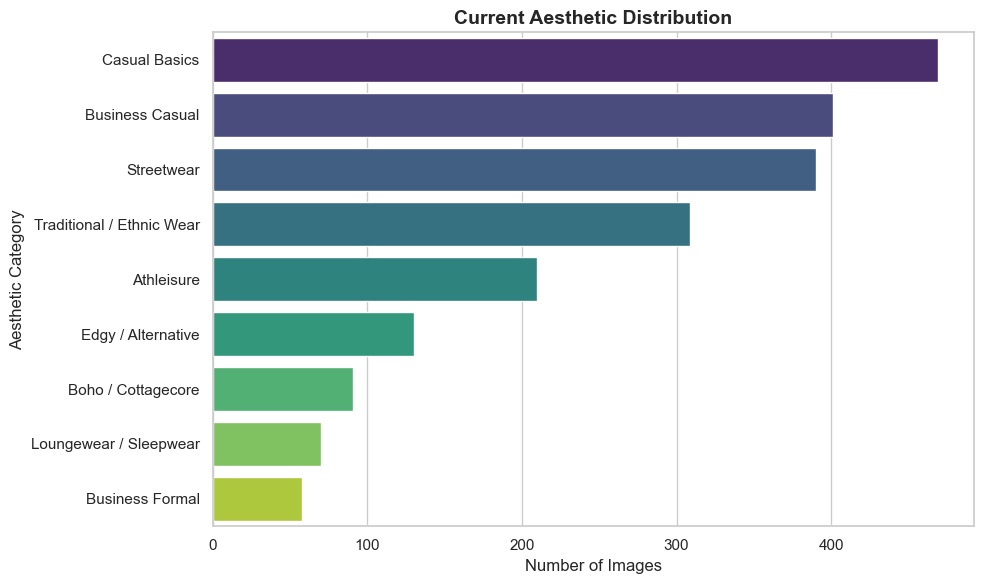

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path remains the same relative to the scripts folder
csv_path = "../my_vibe_model_2/synthetic_aesthetics.csv"
df = pd.read_csv(csv_path)

df_clean = df[df['vibe'] != 'DROP']

print("--- CURRENT DATASET BALANCE ---")
print(df_clean['vibe'].value_counts())
print(f"\nTotal Clean Samples: {len(df_clean)}")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.countplot(data=df_clean, y="vibe", order=df_clean['vibe'].value_counts().index, palette="viridis")
plt.title("Current Aesthetic Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Images")
plt.ylabel("Aesthetic Category")
plt.tight_layout()
plt.show()

Loading Hugging Face dataset...


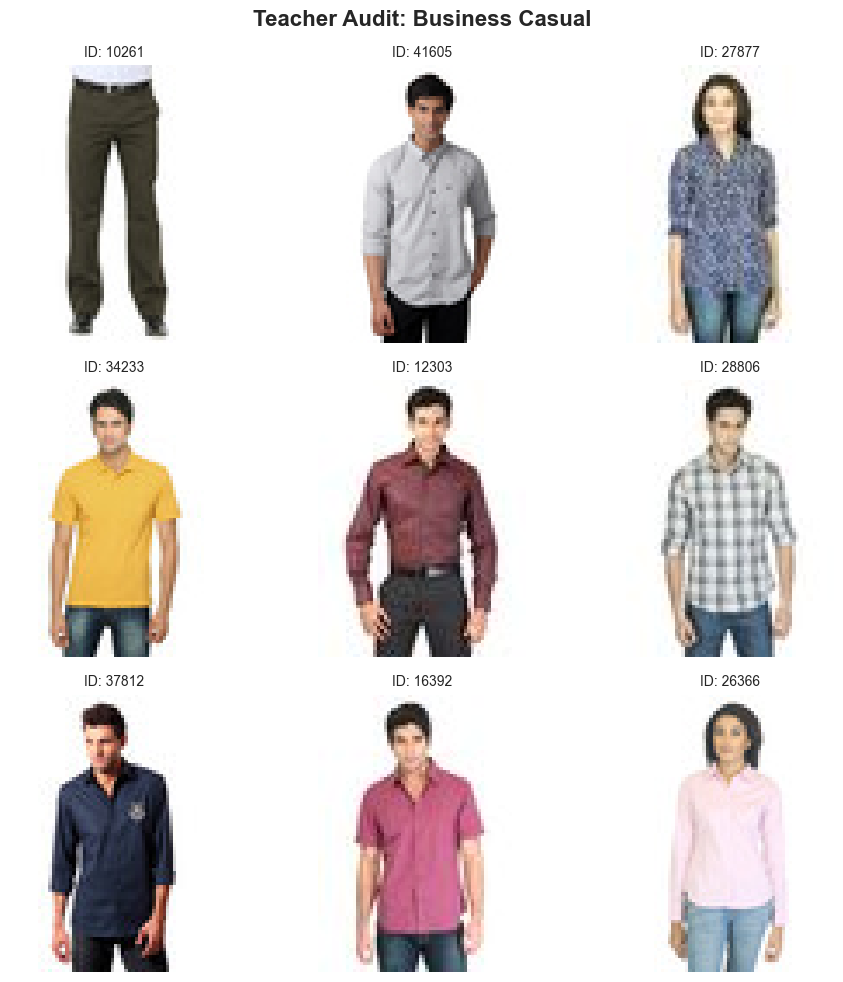

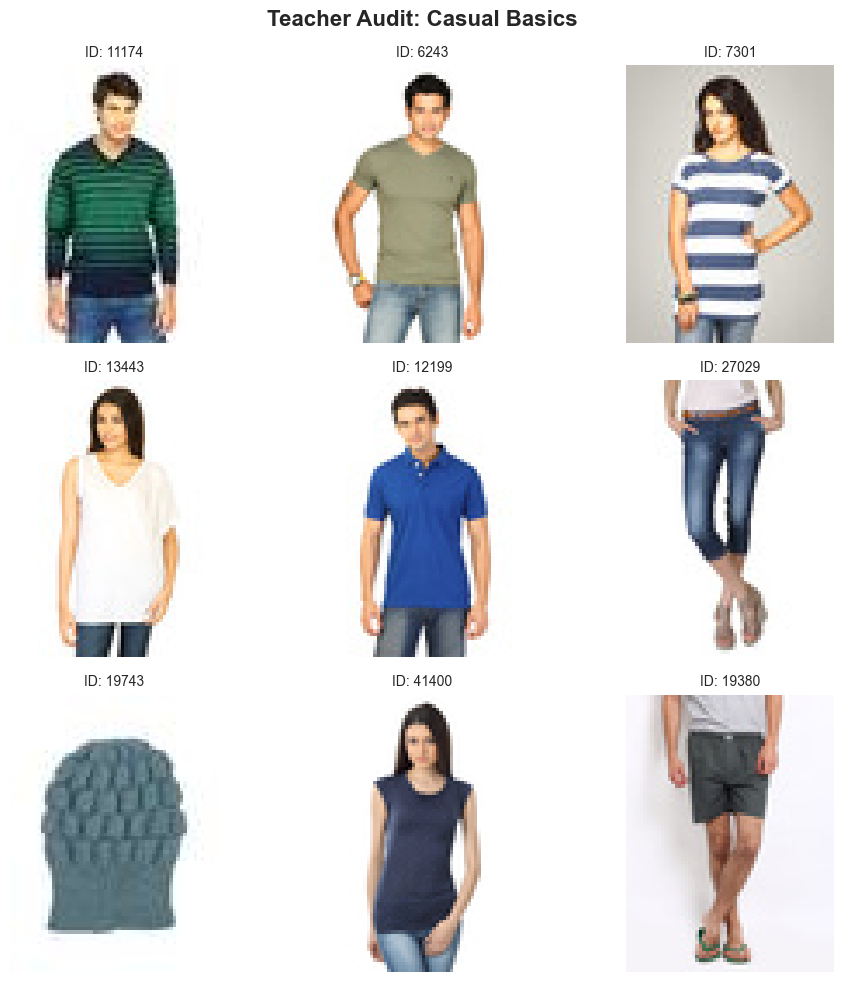

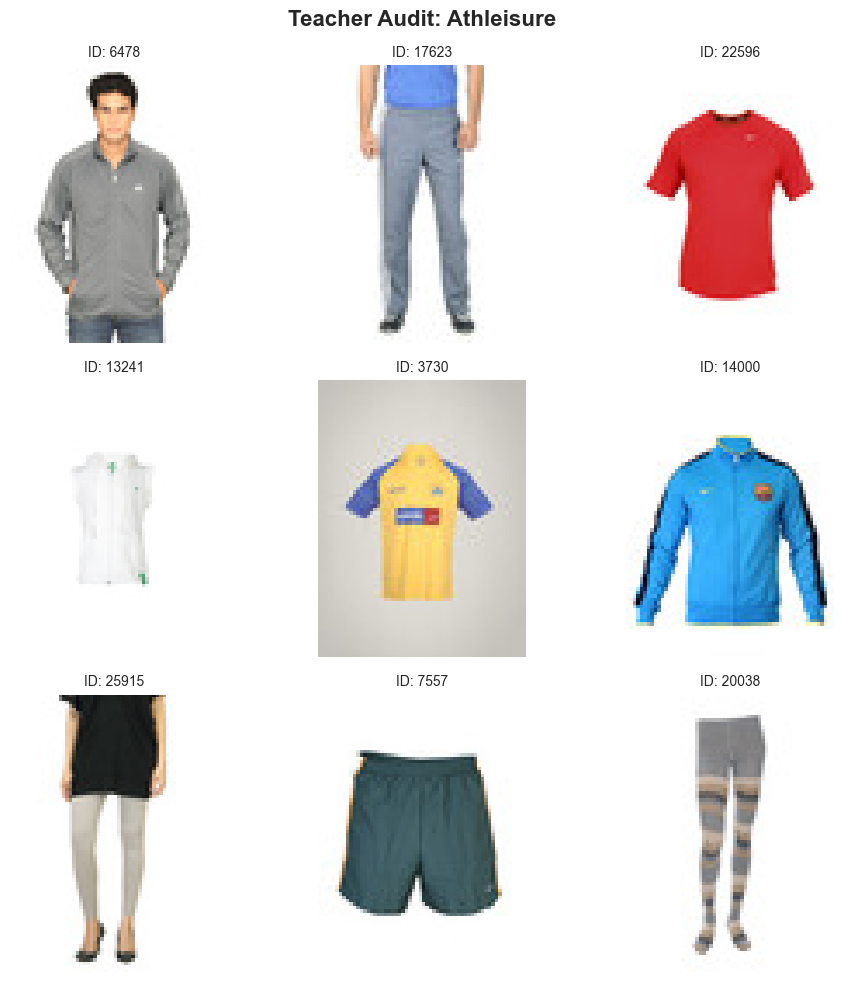

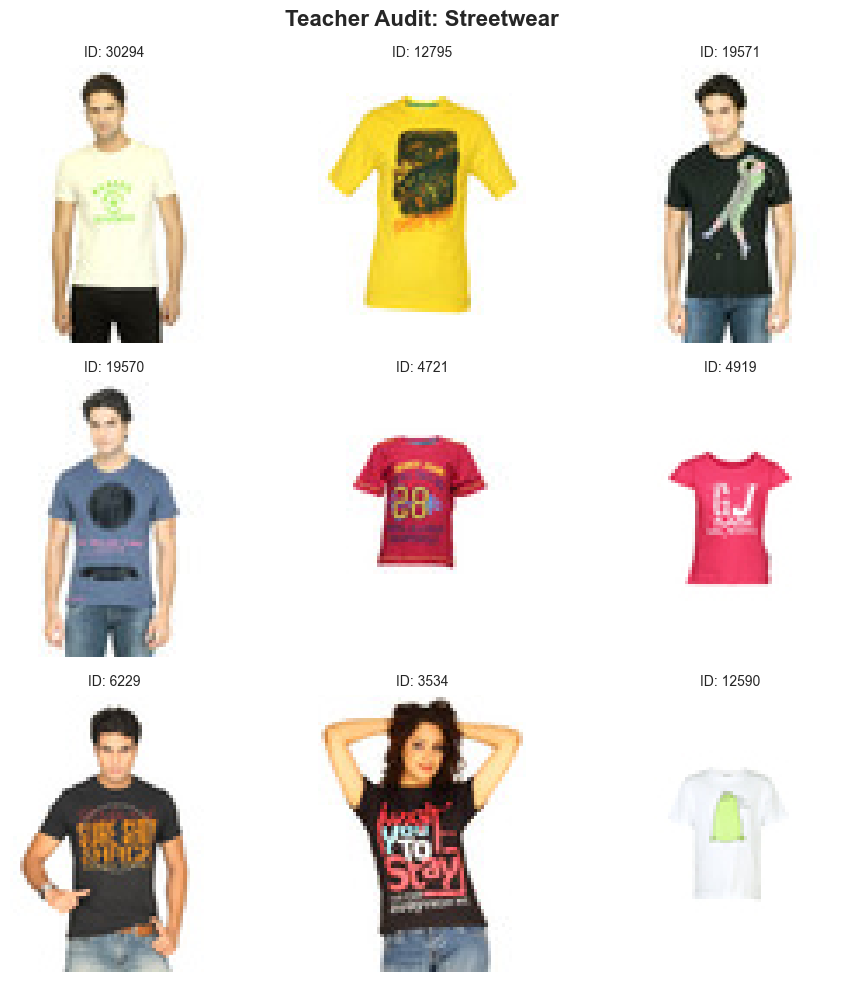

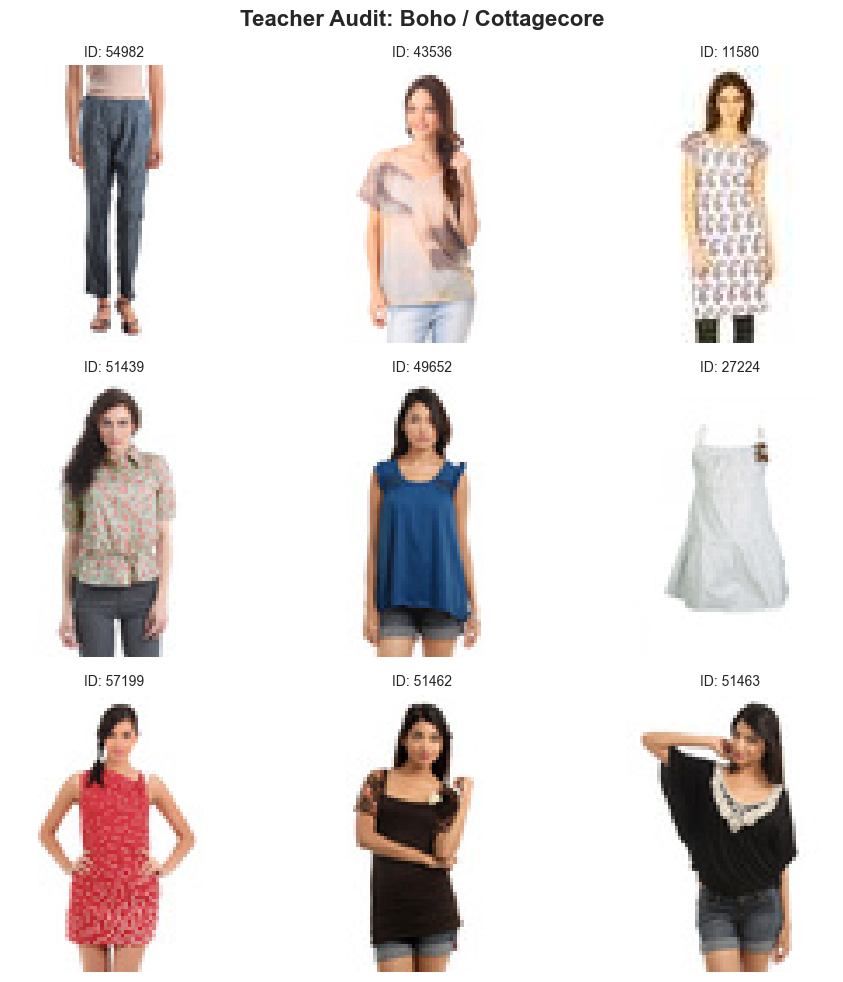

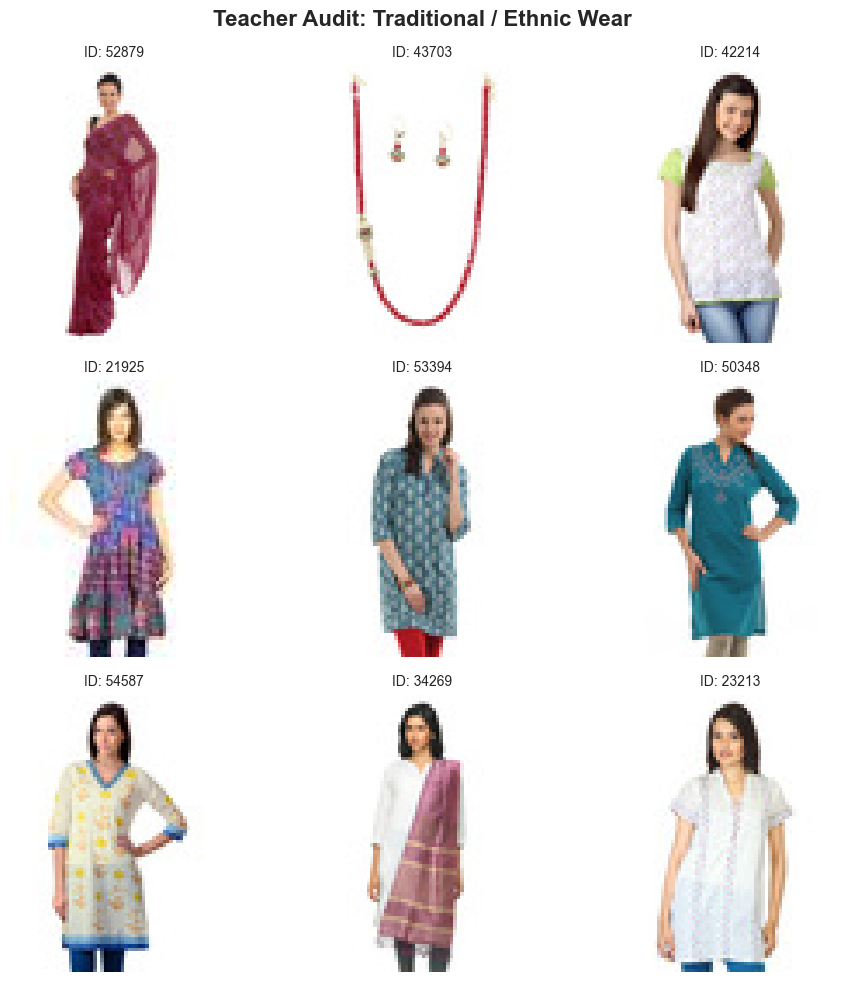

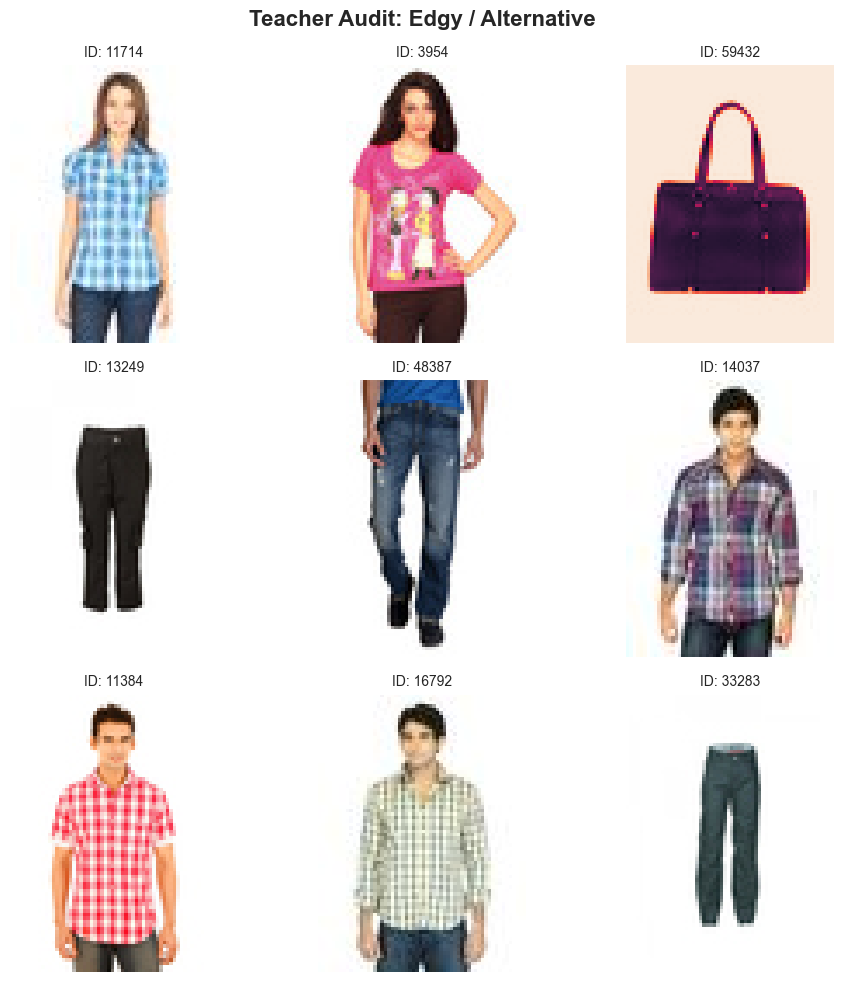

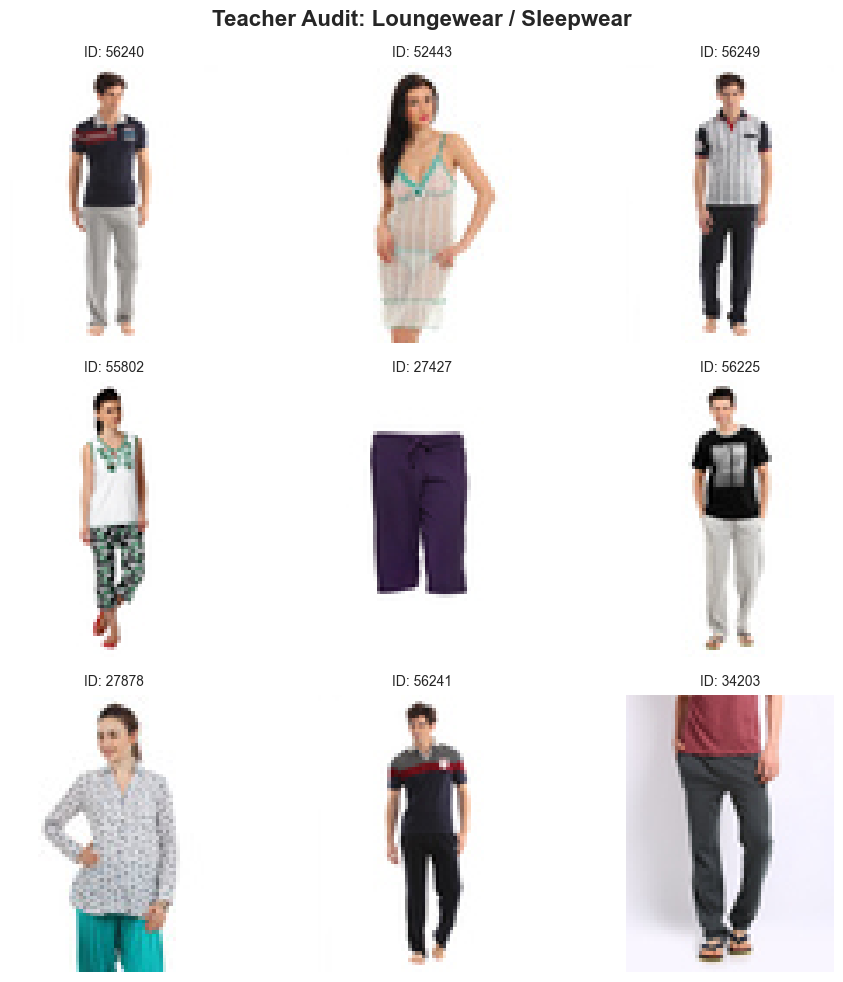

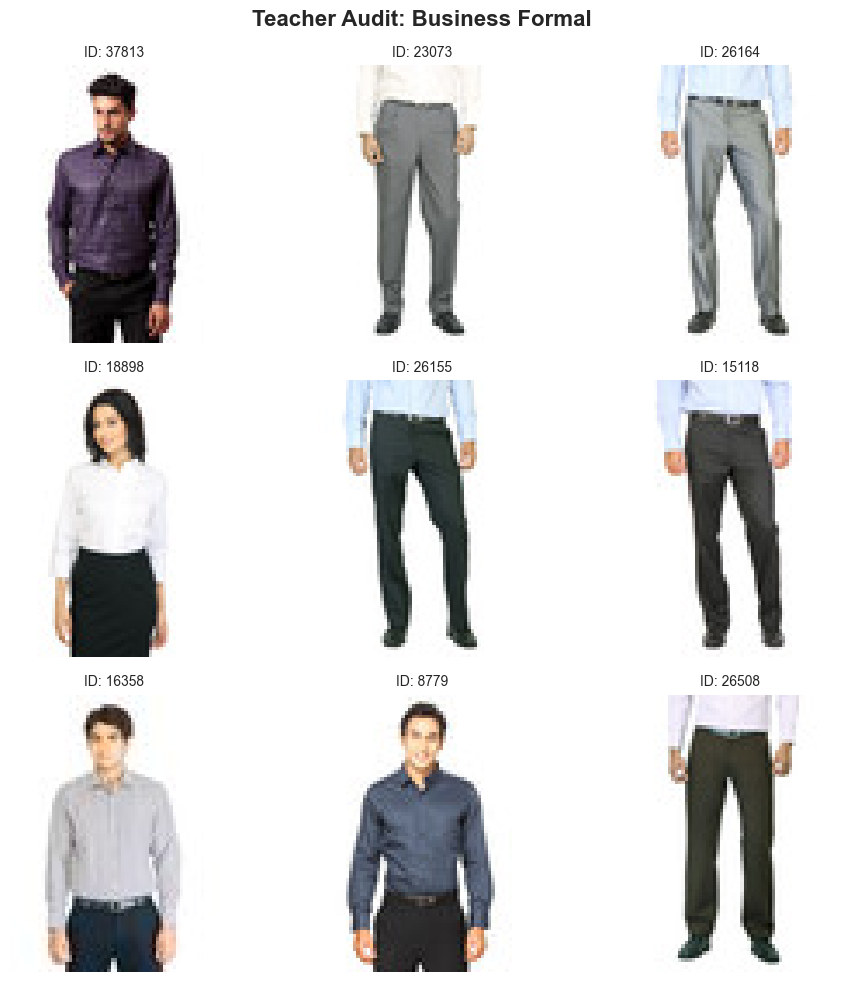

In [6]:
import random
import matplotlib.pyplot as plt
from datasets import load_dataset

print("Loading Hugging Face dataset...")
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")

def audit_local_vibe(target_vibe):
    vibe_df = df_clean[df_clean['vibe'] == target_vibe]
    
    if len(vibe_df) < 9:
        print(f"Not enough samples for {target_vibe} yet. (Only have {len(vibe_df)})")
        return
        
    sample_ids = random.sample(vibe_df['image_id'].astype(int).tolist(), 9)
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.suptitle(f"Teacher Audit: {target_vibe}", fontsize=16, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        img_data = next(item for item in dataset if item["id"] == sample_ids[i])
        ax.imshow(img_data['image'])
        ax.set_title(f"ID: {sample_ids[i]}", fontsize=10)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Test your categories
for i in df_clean['vibe'].unique():
    audit_local_vibe(i)